# Drift Detection Timing Analysis
This notebook analyzes and compares the average drift detection timing for each technique using experiment timing data from CSV and JSON files.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
# Load Timing Data from CSV and JSON
csv_file_path = '../comparison_results/timing_summary.csv'
json_file_path = '../comparison_results/experiment_timing_results.json'

# Load CSV data into a DataFrame
timing_data = pd.read_csv(csv_file_path)

# Load JSON data into a dictionary
with open(json_file_path, 'r') as json_file:
    experiment_data = json.load(json_file)

In [3]:
# Extract Drift Detection Timing per Technique
drift_detection_data = timing_data[timing_data['phase'] == 'drift_detection']
grouped_data = drift_detection_data.groupby('technique')['duration_seconds']

In [4]:
# Compute Average Drift Detection Time per Technique
average_drift_detection_time = grouped_data.mean().sort_values()
print(average_drift_detection_time)

technique
JSDDM       1.879309
HDDDM       2.158357
KSDDM_90    7.297740
KSDDM_95    8.097768
Name: duration_seconds, dtype: float64


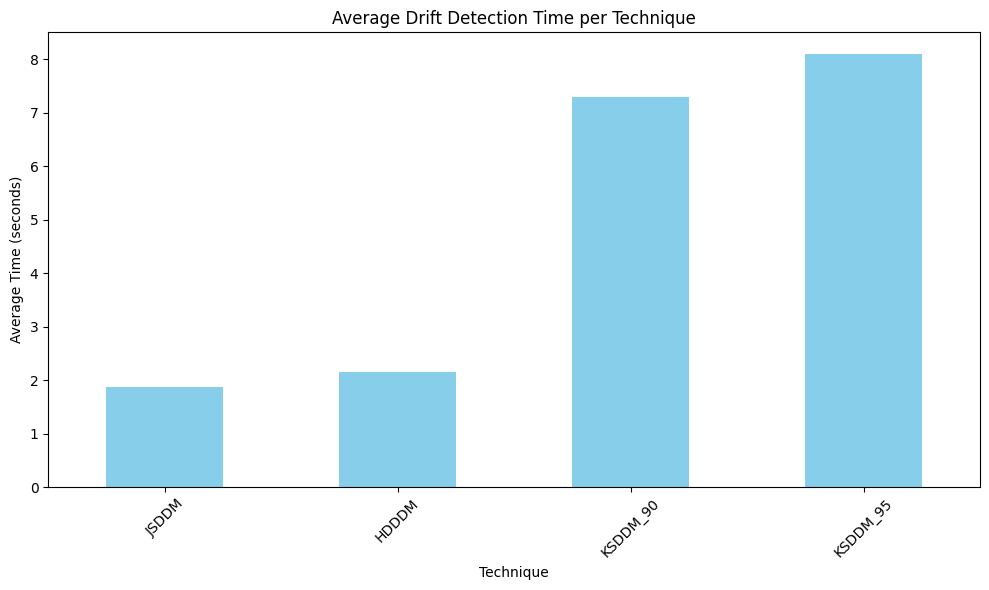

In [ ]:
# Visualize Average Drift Detection Time per Technique
plt.figure(figsize=(10, 6))
average_drift_detection_time.plot(kind='bar', color='skyblue')
plt.title('Average Drift Detection Time per Technique')
plt.xlabel('Technique')
plt.ylabel('Average Time (seconds)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

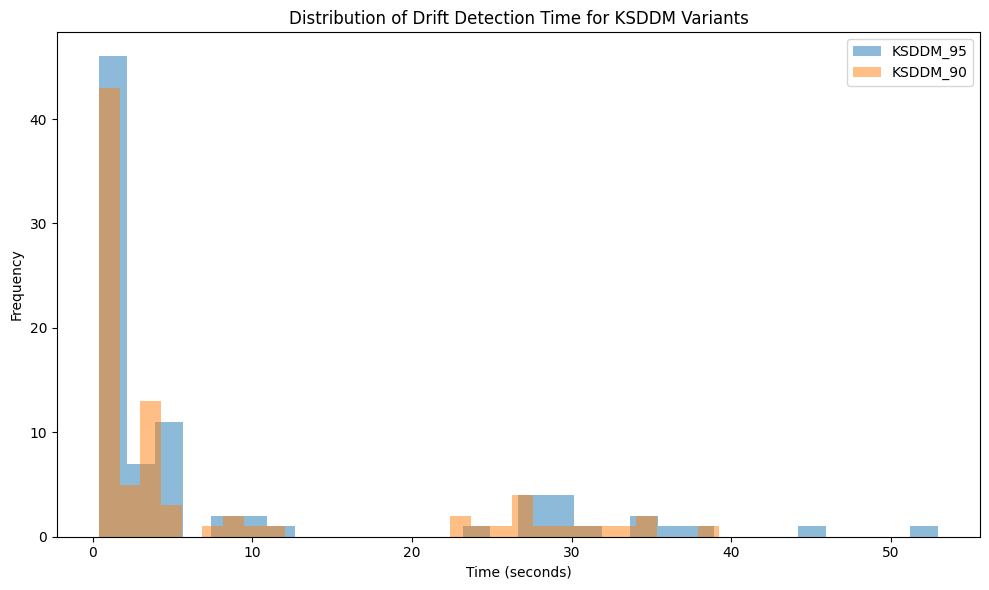

In [ ]:
# Investigate KSDDM Timing
ksddm_data = drift_detection_data[drift_detection_data['technique'].str.contains('KSDDM')]

# Plot distribution of KSDDM timing
plt.figure(figsize=(10, 6))
for technique in ksddm_data['technique'].unique():
    subset = ksddm_data[ksddm_data['technique'] == technique]
    plt.hist(subset['duration_seconds'], bins=30, alpha=0.5, label=technique)

plt.title('Distribution of Drift Detection Time for KSDDM Variants')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

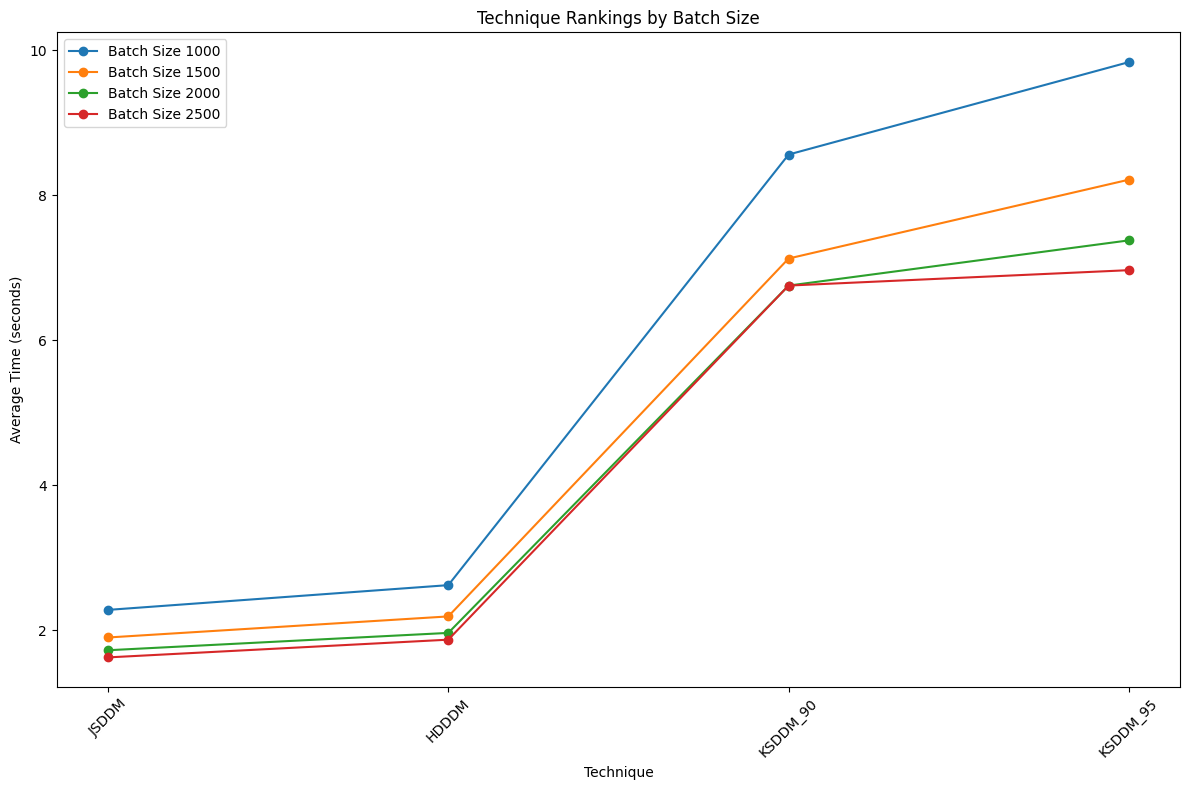

In [ ]:
# Analyze Technique Rankings by Batch Size
batch_size_ranking = drift_detection_data[drift_detection_data['batch_size'] != 'ALL'].groupby(['batch_size', 'technique'])['duration_seconds'].mean().reset_index()
batch_size_ranking = batch_size_ranking.sort_values(['batch_size', 'duration_seconds'])

# Plot rankings for each batch size
unique_batch_sizes = batch_size_ranking['batch_size'].unique()
plt.figure(figsize=(12, 8))
for batch_size in unique_batch_sizes:
    subset = batch_size_ranking[batch_size_ranking['batch_size'] == batch_size]
    plt.plot(subset['technique'], subset['duration_seconds'], marker='o', label=f'Batch Size {batch_size}')

plt.title('Technique Rankings by Batch Size')
plt.xlabel('Technique')
plt.ylabel('Average Time (seconds)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

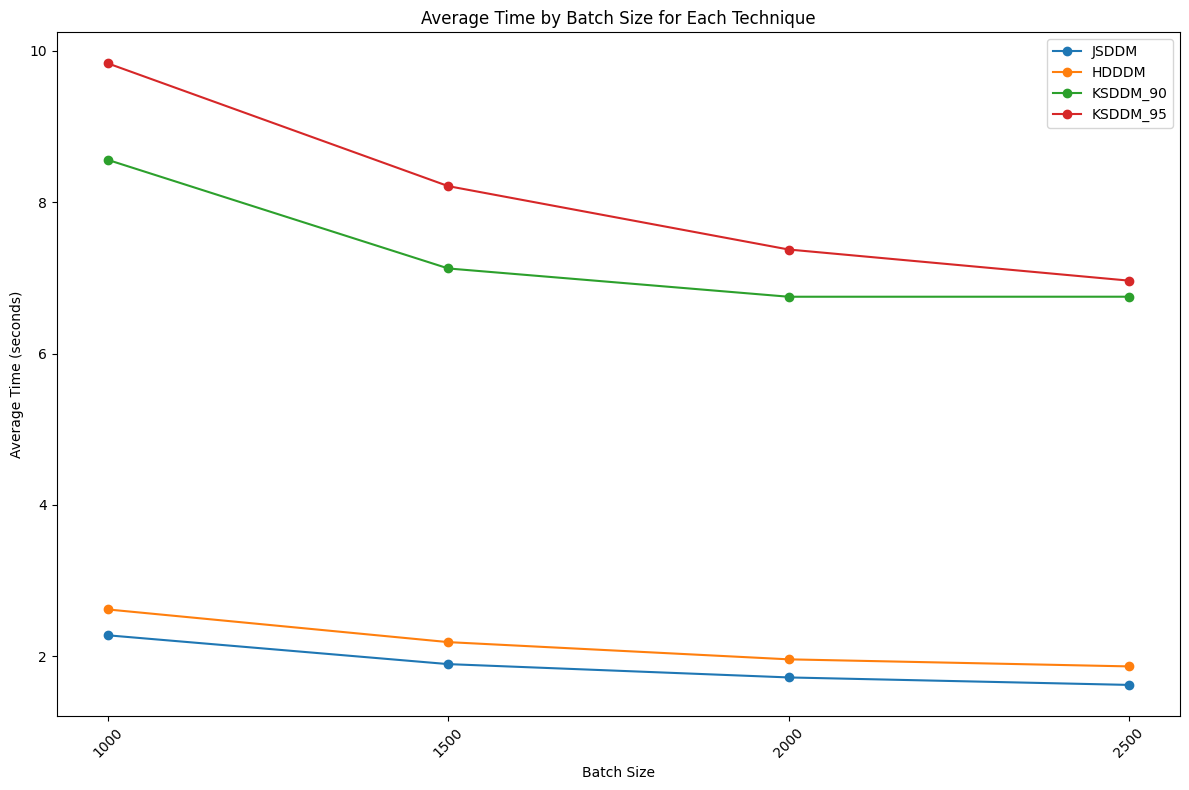

In [ ]:
# Plot batch sizes on the x-axis with lines for each technique
plt.figure(figsize=(12, 8))
unique_techniques = batch_size_ranking['technique'].unique()
for technique in unique_techniques:
    subset = batch_size_ranking[batch_size_ranking['technique'] == technique]
    plt.plot(subset['batch_size'], subset['duration_seconds'], marker='o', label=technique)

plt.title('Average Time by Batch Size for Each Technique (Drift Detection Phase)')
plt.xlabel('Batch Size')
plt.ylabel('Average Time (seconds)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()